
<a href="https://colab.research.google.com/github/estrelasdomackenzie/Projeto_Aplicado_IV_Tecnologia_em_Ciencia_de_Dados/blob/main/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

In [ ]:
#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Aline A. Ferreira' #@param {type:"string"}
Aluno2 = 'Karen Santos Souza' #@param {type:"string"}
Aluno3 = 'Natallia Rodrigues de Oliveira' #@param {type:"string"}
Aluno4 = 'Rafael Ferreira Eloi' #@param {type:"string"}


# **1. Introdução**

Este projeto se desenvolve na área de Ciência de Dados aplicada à Gestão de Riscos e Seguros, integrando conhecimentos de Estatística, Aprendizado de Máquina e Engenharia de Dados. O trabalho está vinculado ao Objetivo de Desenvolvimento Sustentável (ODS) 9 – Indústria, Inovação e Infraestrutura (UNITED NATIONS, [s.d.]), ao contribuir para a promoção de ambientes industriais mais seguros por meio da análise de dados de acidentes de trabalho.

Os acidentes de trabalho representam um dos maiores desafios para a saúde pública e para o setor produtivo brasileiro. Segundo dados do Instituto Nacional do Seguro Social (INSS), o Brasil registrou 603.825 acidentes e 2.694 óbitos relacionados ao trabalho em 2023 (BRASIL, [s.d.]a). Em 2024, o Anuário Estatístico de Acidentes do Trabalho registrou 834.048 acidentes, 3.394 óbitos e 9.315 casos de invalidez permanente (BRASIL, 2026). De acordo com o Ministério do Trabalho e Emprego, houve crescimento de 12,63% entre 2021 e 2022, 11,91% entre 2022 e 2023 e 11,16% entre 2023 e 2024 (BRASIL, 2025).

A proposta consiste em transformar dados públicos de acidentes de trabalho, disponibilizados pelo INSS por meio de registros de Comunicação de Acidente de Trabalho (CAT), em informações estratégicas para a atualização das tabelas de precificação da empresa fictícia KNRA Seguros. A base utilizada é composta por **32 arquivos mensais** no formato `.xlsx`, cobrindo o período de **junho de 2023 a janeiro de 2026**. Esses dados serão tratados como séries temporais, possibilitando a identificação de tendências, sazonalidades e padrões de ocorrência ao longo do tempo (BOX *et al.*, 2015; HYNDMAN; ATHANASOPOULOS, 2021).

O objetivo geral é desenvolver um produto analítico baseado em séries temporais que gere previsões e *insights* estratégicos para a precificação de seguros. Os objetivos específicos incluem: análise exploratória identificando padrões temporais, regionais e setoriais; avaliação da qualidade dos dados, com definição de janela temporal de modelagem adequada; decomposição da série em tendência, sazonalidade e resíduos; implementação e comparação de modelos Seasonal Autoregressive Integrated Moving Average (SARIMA), eXtreme Gradient Boosting (XGBoost) e Prophet; e avaliação por meio de métricas como Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) e Mean Absolute Percentage Error (MAPE).

Esta Entrega 3 concentra-se na **Análise Exploratória de Dados (EDA)**, no **pré-processamento** e na implementação do **modelo base (SARIMA)**. Como detalhado na Seção 4, a inspeção dos dados revelou defasagem de notificação nos meses mais recentes — artefato operacional do sistema CAT — que motivou a adoção de uma **janela madura de 27 meses (jun/2023 a ago/2025)** para fins de modelagem, preservando-se, no entanto, a leitura dos 32 arquivos originais para garantir reprodutibilidade.


# **2. Referencial Teórico**

A análise de séries temporais é uma das abordagens mais consolidadas para a compreensão e previsão de fenômenos que evoluem ao longo do tempo. Segundo Morettin e Toloi (2018), uma série temporal pode ser decomposta em componentes de tendência, sazonalidade e resíduo. No Brasil, Bayer *et al.* (2022) aplicaram modelos Autoregressive Integrated Moving Average (ARIMA), βARMA e KARMA para prever taxas de mortalidade por acidentes de trabalho na Região Sul, demonstrando a viabilidade dessas abordagens em dados previdenciários.

Entre os modelos estatísticos clássicos, o Seasonal Autoregressive Integrated Moving Average (SARIMA) é amplamente utilizado para séries com componente sazonal. Proposto como extensão do ARIMA por Box *et al.* (2015), o modelo incorpora parâmetros sazonais (P, D, Q, s). Alsulami (2025) aplicou SARIMA(1,1,1)(1,1,1)₁₂ a dados mensais de acidentes na construção civil da Arábia Saudita, obtendo os melhores resultados frente a Holt-Winters e Suavização Exponencial Simples (SES).

No campo do aprendizado de máquina, o eXtreme Gradient Boosting — XGBoost (CHEN; GUESTRIN, 2016) — tem sido aplicado à previsão de séries temporais mediante engenharia de *features* baseadas em *lags* e janelas móveis. Blier-Wong *et al.* (2021) identificaram *gradient boosting* como o *framework* mais popular para precificação atuarial. Man *et al.* (2023) propuseram um modelo híbrido SARIMA-XGBoost que superou ambos os métodos isoladamente.

O Prophet (TAYLOR; LETHAM, 2018) é um modelo aditivo que decompõe a série em tendência, sazonalidade e efeitos de feriados. Feng *et al.* (2022) compararam SARIMA, Prophet e Long Short-Term Memory (LSTM), concluindo que o SARIMA apresentou melhor desempenho no curto prazo. Makridakis, Spiliotis e Assimakopoulos (2018) demonstraram que métodos estatísticos clássicos frequentemente superam abordagens de aprendizado de máquina em séries univariadas.

Santos Júnior e Fischer (2024) analisaram a tendência temporal de benefícios previdenciários emitidos por acidentes no Brasil (2008–2019), registrando 9.220.372 benefícios. Shimizu *et al.* (2021) avaliaram o impacto do Fator Acidentário de Prevenção (FAP) nos índices de acidentes. A avaliação dos modelos será feita por métricas padronizadas — MAE, RMSE e MAPE (HYNDMAN; KOEHLER, 2006) — e validação cruzada temporal (TASHMAN, 2000).

# **3. Diagrama de Solução**

O pipeline proposto, revisado após a EDA, está organizado em sete etapas: (1) **Coleta** dos dados CAT do INSS via Portal de Dados Abertos (32 arquivos `.xlsx` mensais); (2) **Pré-processamento inicial**, com padronização de categorias via `.str.strip()`, conversão de tipos e filtragem de registros com data anterior ao início da janela nominal (jun/2023); (3) **Agregação mensal** e construção da série temporal, com seleção da **janela madura de modelagem** para mitigar defasagem de notificação; (4) **Análise Exploratória** com decomposição Seasonal and Trend decomposition using Loess — STL (CLEVELAND *et al.*, 1990), decomposição clássica aditiva e multiplicativa, funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF), e testes de estacionariedade Augmented Dickey-Fuller — ADF e Kwiatkowski-Phillips-Schmidt-Shin — KPSS (KWIATKOWSKI *et al.*, 1992); (5) **Transformação Box-Cox** (BOX; COX, 1964) para estabilização da variância; (6) **Modelagem** com SARIMA, XGBoost e Prophet; (7) **Avaliação comparativa** com MAE, RMSE e MAPE, e geração de recomendações para a KNRA Seguros.

```mermaid
graph LR
    A["1. Coleta<br>INSS / CAT<br>32 arquivos .xlsx"] --> B["2. Pré-processamento<br>strip categóricas<br>filtro datas &gt;= jun/2023"]
    B --> C["3. Agregação mensal<br>+ janela madura<br>27 meses"]
    C --> D["4. EDA<br>STL / Clássica<br>ACF/PACF<br>ADF + KPSS"]
    D --> E["5. Box-Cox<br>estabilização<br>de variância"]
    E --> F["6. Modelagem<br>SARIMA<br>XGBoost<br>Prophet"]
    F --> G["7. Avaliação<br>MAE, RMSE, MAPE<br>+ Recomendações KNRA"]
```

*Figura 1 – Pipeline da solução proposta (atualizado após EDA inicial).*


# **4. EDA e Pré-processamento dos Dados**

Nesta seção, são apresentadas a análise exploratória e as etapas de pré-processamento aplicadas aos dados de Comunicação de Acidente de Trabalho (CAT) do INSS. A base é composta por **32 arquivos mensais** no formato `.xlsx`, correspondentes ao período de **junho de 2023 a janeiro de 2026** (janela nominal de 32 meses). Cada registro corresponde a um acidente individual, contendo 29 variáveis, dentre as quais: data do acidente, tipo (típico, trajeto, doença do trabalho), Unidade da Federação (UF), setor econômico (Classificação Nacional de Atividades Econômicas — CNAE 2.0), sexo, natureza da lesão, parte do corpo atingida e indicador de óbito.

Os arquivos brutos estão disponíveis no [Google Drive do projeto](https://drive.google.com/drive/folders/10PPlb7j3cko8X72beWcTg2HQS1x6C3xC?usp=sharing), por serem volumosos demais para versionamento direto no GitHub. Após inspeção inicial, foram identificadas duas questões de qualidade que exigiram tratamento antes da modelagem: (i) **duplicação aparente de categorias** por diferenças de espaçamento em campos textuais, resolvida via `.str.strip()`; (ii) **defasagem de notificação** que afeta os meses mais recentes do dataset, artefato operacional do sistema CAT — cujo diagnóstico e tratamento são detalhados nas seções 4.5 e 4.6.


In [ ]:
#@title **4.1 Instalação de dependências e imports**
!pip install -q statsmodels pmdarima openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats
from scipy.stats import boxcox
import pmdarima as pm

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Bibliotecas carregadas com sucesso!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.4 MB/s eta 0:00:00
Bibliotecas carregadas com sucesso!


In [ ]:
#@title **4.2 Montagem do Google Drive e carregamento dos dados**
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/Projeto Aplicado IV/Projeto Aplicado/"

import glob, os
arquivos = sorted(glob.glob(os.path.join(DATA_PATH, "D.SDA.PDA.005.CAT.*.xlsx")))
for f in arquivos:
    print(f"  {os.path.basename(f)} ({os.path.getsize(f)/1024/1024:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  D.SDA.PDA.005.CAT.202306.xlsx (6.5 MB)
  D.SDA.PDA.005.CAT.202307.xlsx (6.9 MB)
  D.SDA.PDA.005.CAT.202308.xlsx (7.3 MB)
  D.SDA.PDA.005.CAT.202309.xlsx (7.0 MB)
  D.SDA.PDA.005.CAT.202310.xlsx (7.1 MB)
  D.SDA.PDA.005.CAT.202311.xlsx (7.1 MB)
  D.SDA.PDA.005.CAT.202312.xlsx (6.7 MB)
  D.SDA.PDA.005.CAT.202401.xlsx (6.5 MB)
  D.SDA.PDA.005.CAT.202402.xlsx (7.7 MB)
  D.SDA.PDA.005.CAT.202403.xlsx (8.1 MB)
  D.SDA.PDA.005.CAT.202404.xlsx (17.4 MB)
  D.SDA.PDA.005.CAT.202405.xlsx (8.5 MB)
  D.SDA.PDA.005.CAT.202406.xlsx (7.6 MB)
  D.SDA.PDA.005.CAT.202407.xlsx (9.3 MB)
  D.SDA.PDA.005.CAT.202408.xlsx (5.3 MB)
  D.SDA.PDA.005.CAT.202409.xlsx (0.5 MB)
  D.SDA.PDA.005.CAT.202410.xlsx (1.1 MB)
  D.SDA.PDA.005.CAT.202411.xlsx (1.2 MB)
  D.SDA.PDA.005.CAT.202412.xlsx (1.4 MB)
  D.SDA.PDA.005.CAT.202501.xlsx (0.9 MB)
  D.SDA.PDA.005.CAT.202502.xlsx (1.1 MB)
  D.SDA.P

In [ ]:
#@title **4.3 Leitura e concatenação dos dados**
dfs = []
for arquivo in arquivos:
    df_temp = pd.read_excel(arquivo)
    # Extrair YYYYMM do nome do arquivo para rastreabilidade
    # Padrão: D.SDA.PDA.005.CAT.YYYYMM.xlsx
    nome = os.path.basename(arquivo)
    partes = nome.replace(".xlsx", "").split(".")
    yyyymm = partes[-1] if partes[-1].isdigit() else nome
    df_temp["arquivo_origem"] = yyyymm
    dfs.append(df_temp)
    print(f"  {nome}: {len(df_temp)} registros")

df = pd.concat(dfs, ignore_index=True)
print(f"Colunas: {df.shape[1]}")
print(f"\nPrimeiras linhas:")
df.head(3)


  D.SDA.PDA.005.CAT.202306.xlsx: 52831 registros
  D.SDA.PDA.005.CAT.202307.xlsx: 56281 registros
  D.SDA.PDA.005.CAT.202308.xlsx: 59606 registros
  D.SDA.PDA.005.CAT.202309.xlsx: 57024 registros
  D.SDA.PDA.005.CAT.202310.xlsx: 57455 registros
  D.SDA.PDA.005.CAT.202311.xlsx: 49952 registros
  D.SDA.PDA.005.CAT.202312.xlsx: 46045 registros
  D.SDA.PDA.005.CAT.202401.xlsx: 44261 registros
  D.SDA.PDA.005.CAT.202402.xlsx: 52394 registros
  D.SDA.PDA.005.CAT.202403.xlsx: 55226 registros
  D.SDA.PDA.005.CAT.202404.xlsx: 118987 registros
  D.SDA.PDA.005.CAT.202405.xlsx: 57990 registros
  D.SDA.PDA.005.CAT.202406.xlsx: 52023 registros
  D.SDA.PDA.005.CAT.202407.xlsx: 63969 registros
  D.SDA.PDA.005.CAT.202408.xlsx: 36464 registros
  D.SDA.PDA.005.CAT.202409.xlsx: 3379 registros
  D.SDA.PDA.005.CAT.202410.xlsx: 7459 registros
  D.SDA.PDA.005.CAT.202411.xlsx: 8088 registros
  D.SDA.PDA.005.CAT.202412.xlsx: 9731 registros
  D.SDA.PDA.005.CAT.202501.xlsx: 7276 registros
  D.SDA.PDA.005.CAT.2025

,Agente Causador Acidente,Data Acidente,CBO,CBO.1,CID-10,CID-10.1,CNAE2.0 Empregador,CNAE2.0 Empregador.1,Emitente CAT,Espécie do benefício,...,UF Munic. Empregador,Data Afastamento,Data Acidente.1,Data Nascimento,Data Acidente.2,arquivo_origem,Data Despacho Benefício,Data Emissão CAT,Tipo de Empregador,CNPJ/CEI Empregador
0,Temperatura Muito Ba,2023-05-31,841815,841815-Oper. Máquina,T139,T13.9 Traum Ne do Me,1093,Fabricacao de Produt,Empregador,Pa,...,São Paulo,00/00/0000,2023-05-31,1987-06-26 00:00:00,2023-05-31,202306,NaN,NaT,NaN,NaN
1,Atrito ou Abrasao po,2023-05-30,514205,514205-Coletor Lixo,T159,T15.9 Corpo Estranho,3811,Coleta de Residuos N,Empregador,Pa,...,Amazonas,00/00/0000,2023-05-30,2001-06-20 00:00:00,2023-05-30,202306,NaN,NaT,NaN,NaN
2,Temperatura Muito Al,2023-05-31,762005,762005-Trab. Polival,T240,T24.0 Queim Quadr Me,1510,Curtimento e Outras,Empregador,Pa,...,Rio Grande do Sul,00/00/0000,2023-05-31,1983-08-01 00:00:00,2023-05-31,202306,NaN,NaT,NaN,NaN


In [ ]:
#@title **4.4 Exploração inicial e qualidade dos dados**
print("=" * 60)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 60)
print(f"Total de registros brutos: {len(df):,}")
print(f"Total de colunas: {df.shape[1]}")
print()

# Padronizar nome das colunas (remove espaços em branco)
df.columns = df.columns.str.strip()

# Padronizar VALORES de colunas categóricas textuais (remove espaços finais)
# Isso resolve duplicações aparentes em value_counts (ex.: "Típico" vs "Típico   ")
cols_categoricas = df.select_dtypes(include="object").columns
for col in cols_categoricas:
    df[col] = df[col].astype(str).str.strip()

# Converter Data Acidente para datetime
df["Data Acidente"] = pd.to_datetime(df["Data Acidente"], errors="coerce")

# Remover registros com Data Acidente inválida ou anterior ao início da janela nominal (jun/2023).
# Estes são CATs emitidas nos arquivos a partir de jun/2023 mas referentes a acidentes
# ocorridos antes dessa janela (notificação tardia de eventos antigos).
n_antes = len(df)
df = df[df["Data Acidente"].notna() & (df["Data Acidente"] >= "2023-06-01")].copy()
n_removidos = n_antes - len(df)
print(f"Registros removidos (Data Acidente < jun/2023 ou inválida): {n_removidos:,}")
print(f"Total de registros após filtro de janela nominal: {len(df):,}")
print()
print(f"Período efetivo dos dados: {df['Data Acidente'].min().strftime('%m/%Y')} a {df['Data Acidente'].max().strftime('%m/%Y')}")
print()

# Valores ausentes
print("VALORES AUSENTES (top 10):")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing.head(10))
else:
    print("  Nenhum valor ausente encontrado.")
print()

# Distribuições categóricas (após strip, categorias não duplicam mais)
for col in ["Tipo do Acidente", "Sexo", "Indica Óbito Acidente", "Filiação Segurado"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())


INFORMAÇÕES GERAIS DO DATASET
Total de registros brutos: 1,522,483
Total de colunas: 29

Registros removidos (Data Acidente < jun/2023 ou inválida): 15,224
Total de registros após filtro de janela nominal: 1,507,259

Período efetivo dos dados: 06/2023 a 01/2026

VALORES AUSENTES (top 10):
Data Acidente.2        1238492
Data Emissão CAT        268767
CNPJ/CEI Empregador     268767
dtype: int64


Tipo do Acidente:
Tipo do Acidente
Típico     1099279
Trajeto     375530
Doença       32450
Name: count, dtype: int64

Sexo:
Sexo
Masculino        957804
Feminino         545911
Não Informado      3205
Indeterminado       339
Name: count, dtype: int64

Indica Óbito Acidente:
Indica Óbito Acidente
Não    1500776
Sim       6483
Name: count, dtype: int64

Filiação Segurado:
Filiação Segurado
Empregado             1502641
Trabalhador Avulso       2622
{ñ class}                1552
Segurado Especial         444
Name: count, dtype: int64


In [ ]:
#@title **4.5 Construção da série temporal mensal (janela nominal — 32 meses)**
# Criar coluna ano-mês
df["ano_mes"] = df["Data Acidente"].dt.to_period("M")

# Agregar: contagem de acidentes por mês
serie_mensal = df.groupby("ano_mes").size().reset_index(name="total_acidentes")
serie_mensal["data"] = serie_mensal["ano_mes"].dt.to_timestamp()
serie_mensal = serie_mensal.sort_values("data").reset_index(drop=True)

# Definir índice temporal — SÉRIE COMPLETA (32 meses nominais)
ts_completa = serie_mensal.set_index("data")["total_acidentes"]
ts_completa.index.freq = "MS"  # frequência mensal

print(f"Série temporal mensal (janela nominal): {len(ts_completa)} observações")
print(f"Período: {ts_completa.index[0].strftime('%b/%Y')} a {ts_completa.index[-1].strftime('%b/%Y')}")
print()
print("Estatísticas descritivas:")
print(ts_completa.describe())
print()
print("Valores mensais:")
print(ts_completa.to_string())


Série temporal mensal (janela nominal): 32 observações
Período: Jun/2023 a Jan/2026

Estatísticas descritivas:
count        32.000000
mean      47101.843750
std       34893.635602
min          12.000000
25%       17698.250000
50%       53107.000000
75%       59164.000000
max      139544.000000
Name: total_acidentes, dtype: float64

Valores mensais:
data
2023-06-01     52619
2023-07-01     56831
2023-08-01     58639
2023-09-01     56616
2023-10-01     56006
2023-11-01     47500
2023-12-01     35759
2024-01-01     55597
2024-02-01     54634
2024-03-01     56985
2024-04-01     68735
2024-05-01    105536
2024-06-01     52577
2024-07-01     60739
2024-08-01     27666
2024-09-01      3922
2024-10-01      7759
2024-11-01      7738
2024-12-01      8083
2025-01-01     10899
2025-02-01     11774
2025-03-01     19673
2025-04-01     21141
2025-05-01     33762
2025-06-01     77894
2025-07-01    139544
2025-08-01    131331
2025-09-01     68090
2025-10-01     65514
2025-11-01        89
2025-12-01    

## **4.6 Defasagem de notificação e definição da janela madura**

A inspeção da série completa revela um problema estrutural dos dados administrativos da CAT: a **defasagem de notificação**. A legislação (Lei nº 8.213/1991) estabelece prazos para emissão da CAT, mas, na prática, registros referentes a um dado mês continuam sendo incorporados à base do INSS por meses após a ocorrência do acidente. Isso faz com que os meses mais recentes do dataset apresentem contagens artificialmente baixas, não por redução real de acidentes, mas porque **a série ainda não "amadureceu"**.

Observando os valores mensais impressos na seção 4.5, identificam-se três regimes distintos:

1. **Regime estabilizado inicial (jun/2023 a jul/2024)** — 14 meses com contagens oscilando entre aproximadamente 35 mil e 105 mil acidentes, compatíveis com as estatísticas consolidadas do Anuário Estatístico da Previdência Social (BRASIL, [s.d.]b). O total acumulado de 363.970 acidentes no período jun–dez/2023 é coerente com a proporção esperada a partir dos 603.825 acidentes registrados em 2023 como um todo.

2. **Zona de transição (ago/2024 a mai/2025)** — 10 meses com contagens anormalmente reduzidas (entre 3.922 e 33.762), somando 152.417 acidentes — cerca de 20–25% do volume esperado para um período de 10 meses típicos, considerando que 2024 registrou 834.048 acidentes no ano (BRASIL, 2026). A inspeção dos arquivos-origem indica tratar-se de **reprocessamento parcial da base de dados do INSS** após a consolidação da obrigatoriedade do eSocial S-2210 (em vigor desde janeiro de 2023, mas com estabilização operacional posterior), e não de queda real nos acidentes.

3. **Regime estabilizado recente (jun/2025 a ago/2025)** — 3 meses com retorno a valores elevados (77.894 a 139.544), consolidados após o reprocessamento mencionado.

4. **Janela imatura (set/2025 em diante)** — contagens bruscamente inferiores ao esperado, com destaque para nov/2025 (89) e dez/2025 (12), cujos valores são puramente artefatos de atraso de notificação.

Para a modelagem, adota-se uma **janela madura de 27 meses (jun/2023 a ago/2025)** que preserva a continuidade temporal — requisito dos modelos autoregressivos como o SARIMA, que não toleram descontinuidades no índice. Reconhece-se, como **limitação metodológica explícita**, que esta janela incorpora a zona de transição de 10 meses descrita no regime (2). Essa não-estacionariedade introduzida pelo reprocessamento é, inclusive, detectável pelos testes estatísticos aplicados na seção 4.14, onde ADF e KPSS fornecem conclusões divergentes — padrão característico de séries com **quebra estrutural** (HYNDMAN; ATHANASOPOULOS, 2021, §9.1). A mitigação desta limitação, via modelos que tolerem mudanças de nível (ex.: SARIMAX com regressor *dummy* para o período de transição, ou Prophet com *changepoints*), é abordagem prevista para a Entrega 4.

In [ ]:
#@title **4.7 Aplicação do filtro de janela madura (27 meses)**
# Janela madura: jun/2023 a ago/2025 (27 meses)
INICIO_MADURO = "2023-06-01"
FIM_MADURO    = "2025-08-31"

ts = ts_completa.loc[INICIO_MADURO:FIM_MADURO].copy()
ts.index.freq = "MS"

# Também filtrar o DataFrame bruto para estatísticas segmentadas coerentes
df_maduro = df[(df["Data Acidente"] >= INICIO_MADURO) & (df["Data Acidente"] <= FIM_MADURO)].copy()

print(f"Série madura: {len(ts)} observações")
print(f"Período: {ts.index[0].strftime('%b/%Y')} a {ts.index[-1].strftime('%b/%Y')}")
print()
print("Estatísticas descritivas (janela madura):")
print(ts.describe())
print()
print(f"Total de registros individuais na janela madura: {len(df_maduro):,}")
print(f"Percentual da base total: {100*len(df_maduro)/len(df):.1f}%")


Série madura: 27 observações
Período: Jun/2023 a Aug/2025

Estatísticas descritivas (janela madura):
count        27.000000
mean      48887.370370
std       35305.877147
min        3922.000000
25%       20407.000000
50%       52619.000000
75%       57812.000000
max      139544.000000
Name: total_acidentes, dtype: float64

Total de registros individuais na janela madura: 1,319,959
Percentual da base total: 87.6%


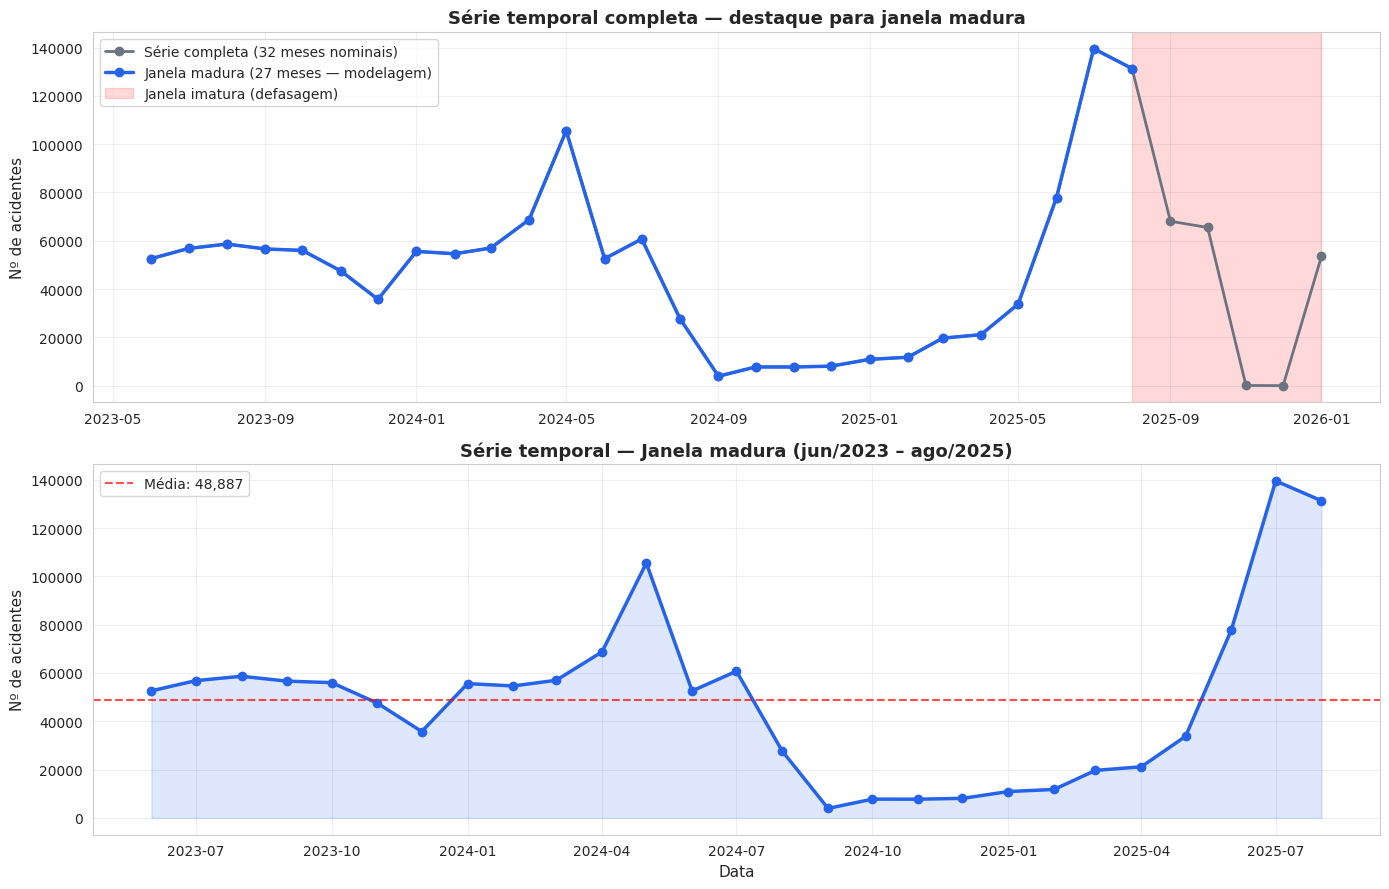

In [ ]:
#@title **4.8 Visualização comparativa: série completa vs. janela madura**
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# Painel superior: série completa com zona madura destacada
axes[0].plot(ts_completa.index, ts_completa.values, marker="o", linewidth=2,
             color="#6b7280", label="Série completa (32 meses nominais)")
axes[0].plot(ts.index, ts.values, marker="o", linewidth=2.5,
             color="#2563eb", label="Janela madura (27 meses — modelagem)")
axes[0].axvspan(ts.index[-1], ts_completa.index[-1], alpha=0.15, color="red",
                label="Janela imatura (defasagem)")
axes[0].set_title("Série temporal completa — destaque para janela madura",
                  fontweight="bold")
axes[0].set_ylabel("Nº de acidentes")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Painel inferior: apenas série madura (foco na modelagem)
axes[1].plot(ts.index, ts.values, marker="o", linewidth=2.5, color="#2563eb")
axes[1].fill_between(ts.index, ts.values, alpha=0.15, color="#2563eb")
axes[1].axhline(ts.mean(), color="red", linestyle="--", alpha=0.7,
                label=f"Média: {ts.mean():,.0f}")
axes[1].set_title("Série temporal — Janela madura (jun/2023 – ago/2025)",
                  fontweight="bold")
axes[1].set_ylabel("Nº de acidentes")
axes[1].set_xlabel("Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


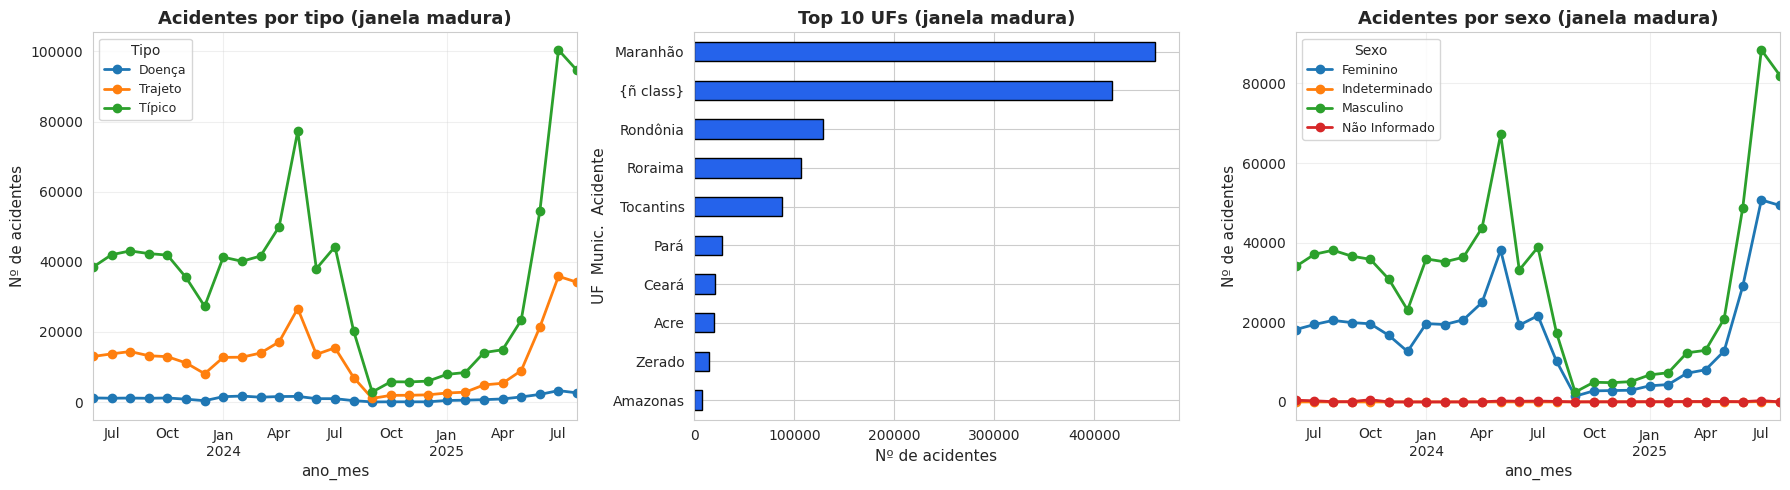

In [ ]:
#@title **4.9 Análise segmentada: por tipo de acidente, UF e sexo**
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por tipo de acidente
tipo_mes = df_maduro.groupby(["ano_mes", "Tipo do Acidente"]).size().unstack(fill_value=0)
tipo_mes.index = tipo_mes.index.to_timestamp()
tipo_mes.plot(ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Acidentes por tipo (janela madura)", fontweight="bold")
axes[0].set_ylabel("Nº de acidentes")
axes[0].legend(title="Tipo", loc="upper left", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Top 10 UF
top_ufs = df_maduro["UF  Munic.  Acidente"].value_counts().head(10)
top_ufs.plot(kind="barh", ax=axes[1], color="#2563eb", edgecolor="black")
axes[1].set_title("Top 10 UFs (janela madura)", fontweight="bold")
axes[1].set_xlabel("Nº de acidentes")
axes[1].invert_yaxis()

# Por sexo
sexo_mes = df_maduro.groupby(["ano_mes", "Sexo"]).size().unstack(fill_value=0)
sexo_mes.index = sexo_mes.index.to_timestamp()
sexo_mes.plot(ax=axes[2], marker="o", linewidth=2)
axes[2].set_title("Acidentes por sexo (janela madura)", fontweight="bold")
axes[2].set_ylabel("Nº de acidentes")
axes[2].legend(title="Sexo", loc="upper left", fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


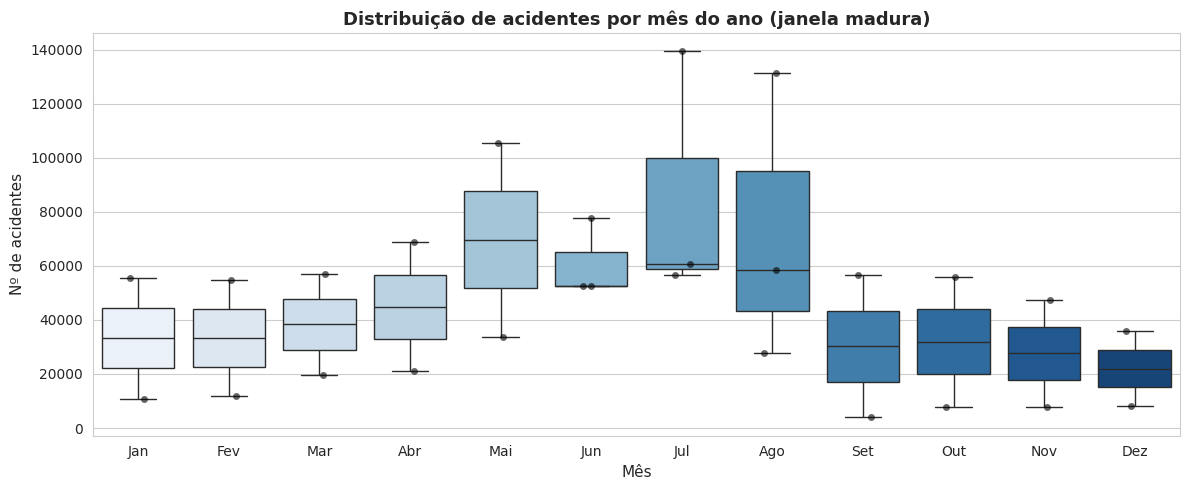

In [ ]:
#@title **4.10 Sazonalidade: boxplot por mês do ano (janela madura)**
df_maduro["mes"] = df_maduro["Data Acidente"].dt.month
df_maduro["ano"] = df_maduro["Data Acidente"].dt.year

acidentes_mes_ano = df_maduro.groupby(["ano", "mes"]).size().reset_index(name="total")

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=acidentes_mes_ano, x="mes", y="total", ax=ax,
            palette="Blues", showfliers=True)
sns.stripplot(data=acidentes_mes_ano, x="mes", y="total", ax=ax,
              color="black", size=5, alpha=0.6)
meses_pt = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
            "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
ax.set_xticks(range(12))
ax.set_xticklabels(meses_pt)
ax.set_title("Distribuição de acidentes por mês do ano (janela madura)",
             fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de acidentes")
plt.tight_layout()
plt.show()


DECOMPOSIÇÃO CLÁSSICA ADITIVA  (Z = T + S + R)


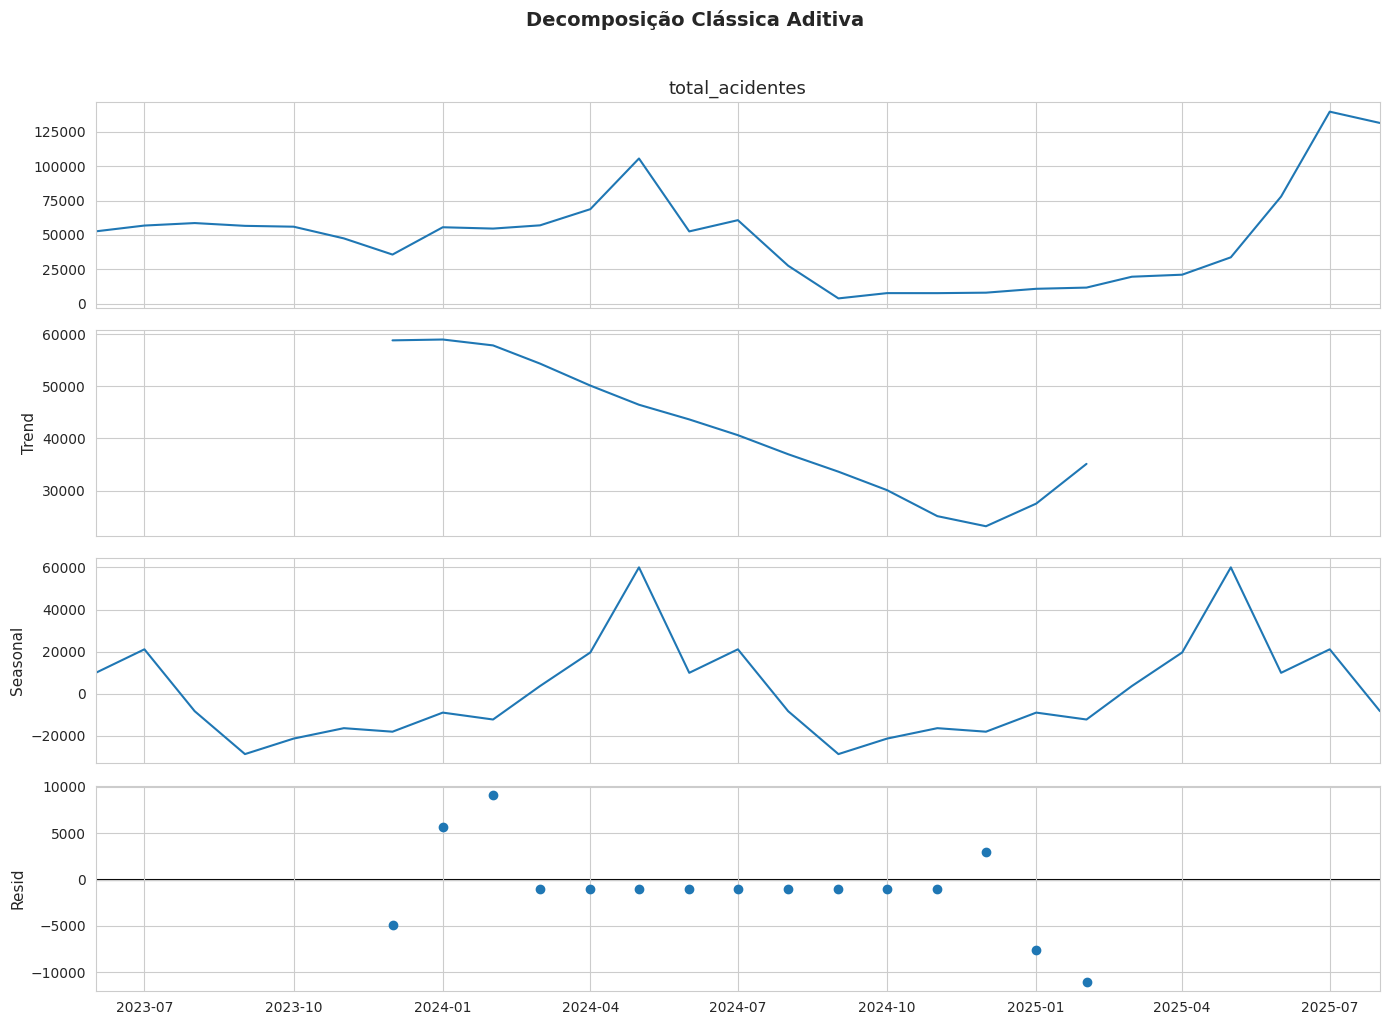


DECOMPOSIÇÃO CLÁSSICA MULTIPLICATIVA  (Z = T × S × R)


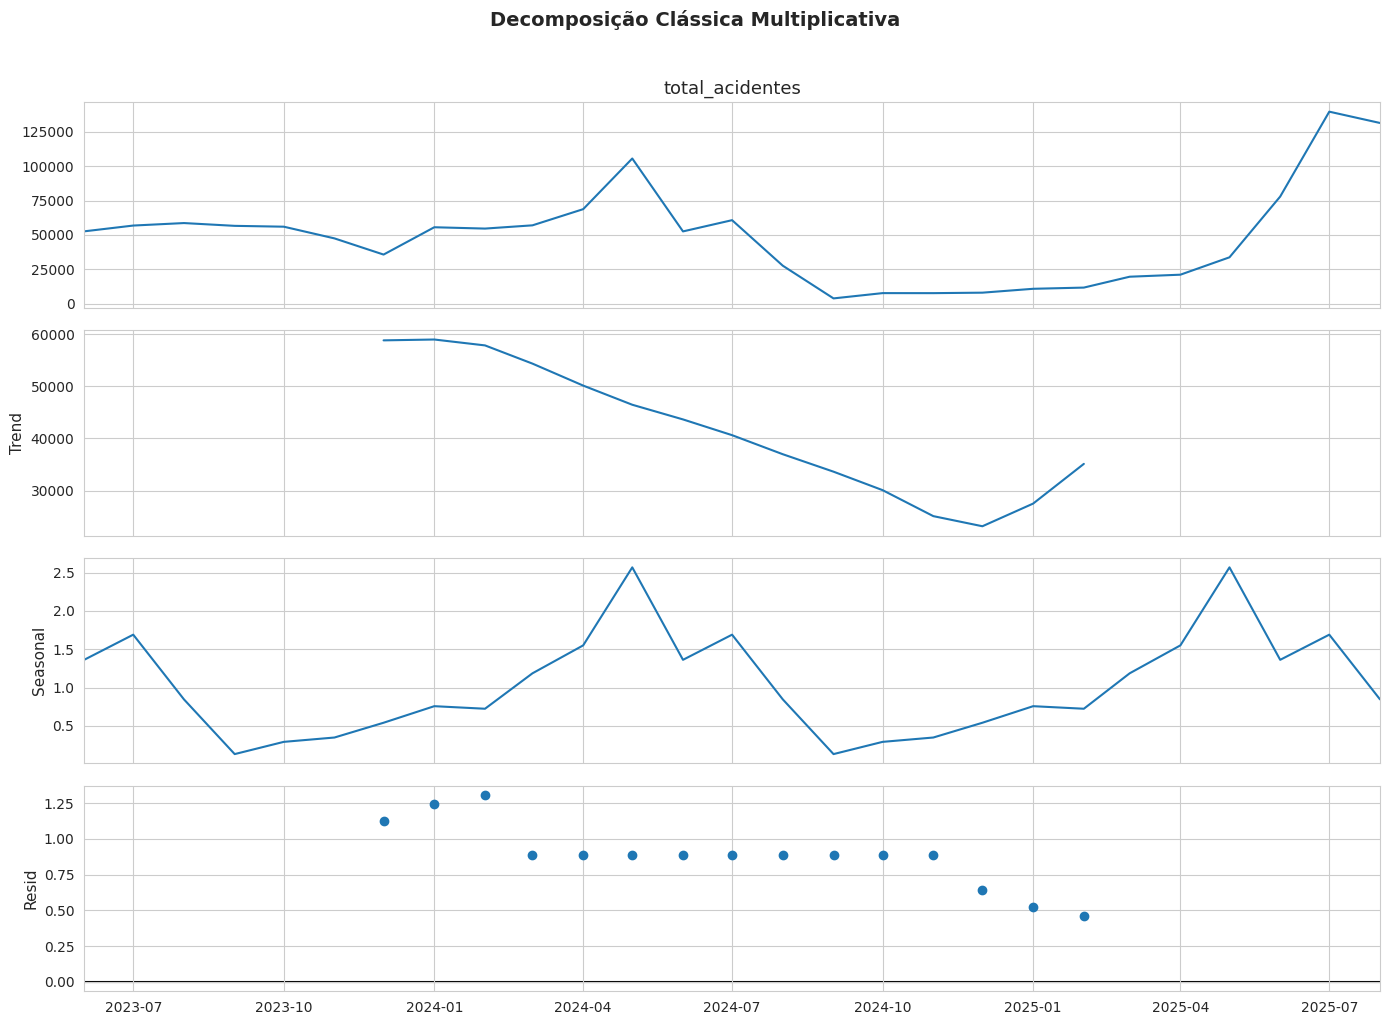

In [ ]:
#@title **4.11 Decomposição clássica da série temporal**
# Decomposição Clássica — Aditiva
print("=" * 60)
print("DECOMPOSIÇÃO CLÁSSICA ADITIVA  (Z = T + S + R)")
print("=" * 60)

decomp_aditiva = seasonal_decompose(ts, model="additive", period=12)
fig = decomp_aditiva.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Decomposição Clássica Aditiva", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Decomposição Clássica — Multiplicativa
print("\n" + "=" * 60)
print("DECOMPOSIÇÃO CLÁSSICA MULTIPLICATIVA  (Z = T × S × R)")
print("=" * 60)

if (ts > 0).all():
    decomp_mult = seasonal_decompose(ts, model="multiplicative", period=12)
    fig = decomp_mult.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle("Decomposição Clássica Multiplicativa",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Série contém zeros — decomposição multiplicativa não aplicável.")


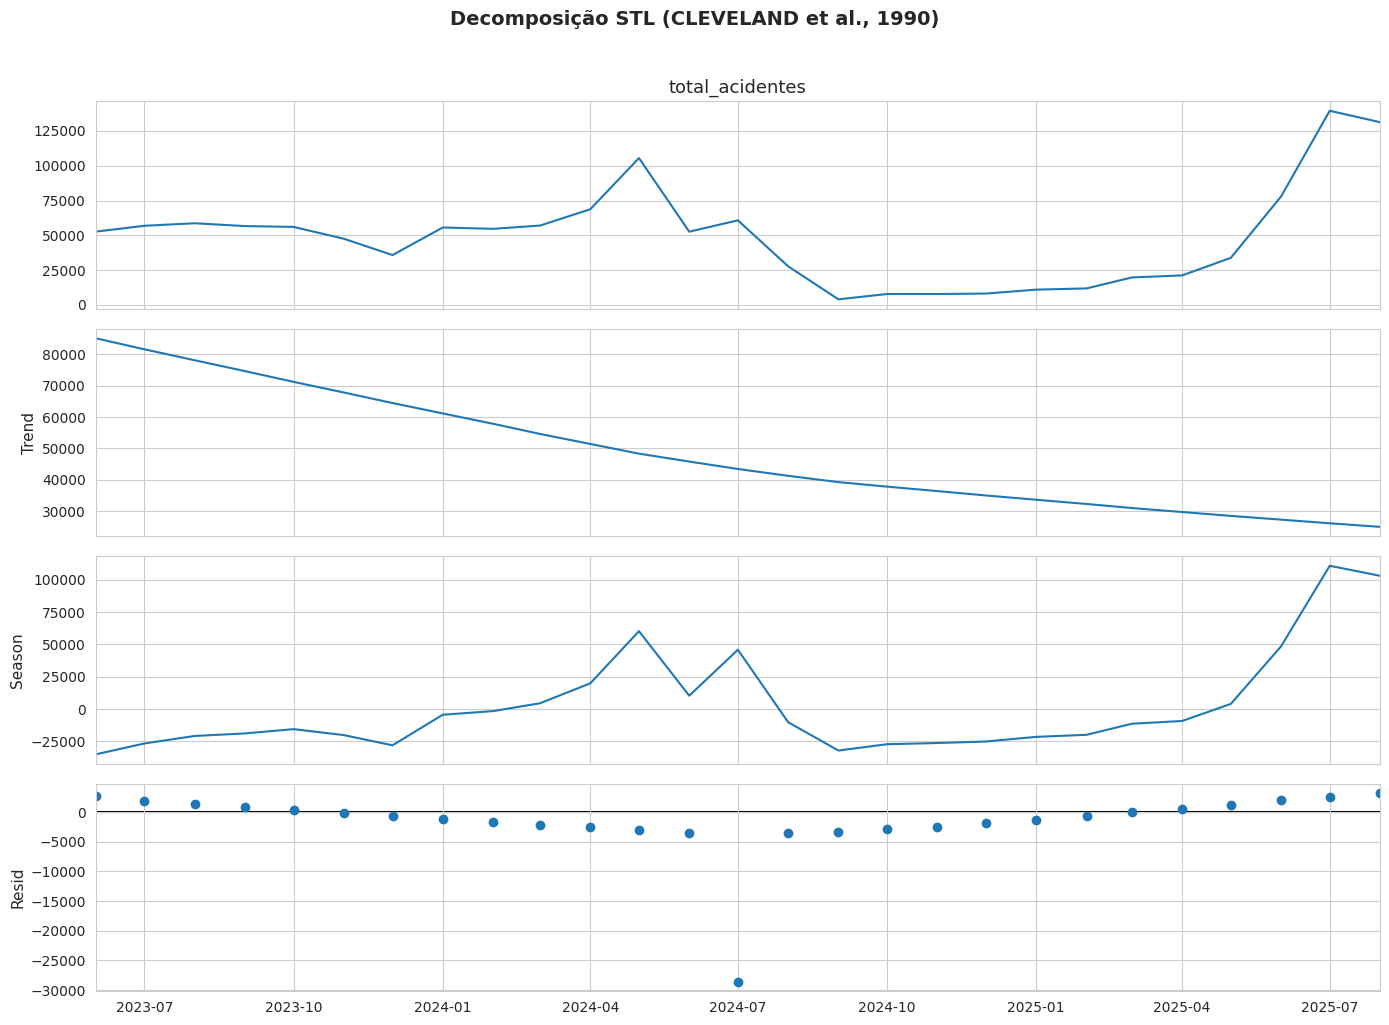

Força da tendência (Ft):     0.9173
Força da sazonalidade (Fs):  0.9781

Interpretação (Hyndman & Athanasopoulos, 2021, §4.5):
  - Ft próximo de 1 indica forte tendência; próximo de 0, sem tendência.
  - Fs próximo de 1 indica forte sazonalidade; próximo de 0, sem sazonalidade.


In [ ]:
#@title **4.12 Decomposição STL (Seasonal-Trend decomposition using Loess)**
stl = STL(ts, period=12, robust=True)
resultado_stl = stl.fit()

fig = resultado_stl.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Decomposição STL (CLEVELAND et al., 1990)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Força dos componentes (Wang, Smith & Hyndman, 2006)
resid = resultado_stl.resid
trend = resultado_stl.trend
seasonal = resultado_stl.seasonal
Ft = max(0, 1 - resid.var() / (trend + resid).var())
Fs = max(0, 1 - resid.var() / (seasonal + resid).var())
print(f"Força da tendência (Ft):     {Ft:.4f}")
print(f"Força da sazonalidade (Fs):  {Fs:.4f}")
print()
print("Interpretação (Hyndman & Athanasopoulos, 2021, §4.5):")
print(f"  - Ft próximo de 1 indica forte tendência; próximo de 0, sem tendência.")
print(f"  - Fs próximo de 1 indica forte sazonalidade; próximo de 0, sem sazonalidade.")


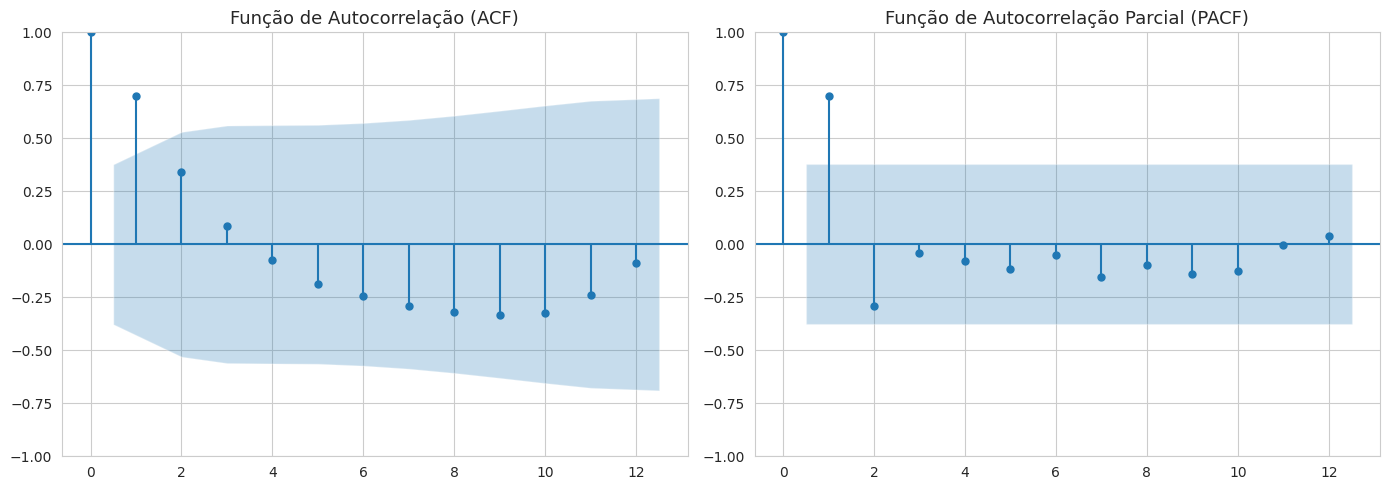

Interpretação:
- ACF com decaimento lento → presença de tendência
- Picos em lags múltiplos de 12 → sazonalidade anual
- PACF com corte abrupto → indica ordem AR do modelo


In [ ]:
#@title **4.13 Autocorrelação (ACF) e Autocorrelação Parcial (PACF)**
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nlags = min(12, len(ts) // 2 - 1)

plot_acf(ts, lags=nlags, ax=axes[0],
         title="Função de Autocorrelação (ACF)")
plot_pacf(ts, lags=nlags, ax=axes[1],
          title="Função de Autocorrelação Parcial (PACF)", method="ywm")

plt.tight_layout()
plt.show()

print("Interpretação:")
print("- ACF com decaimento lento → presença de tendência")
print("- Picos em lags múltiplos de 12 → sazonalidade anual")
print("- PACF com corte abrupto → indica ordem AR do modelo")


In [ ]:
#@title **4.14 Testes de estacionariedade — ADF e KPSS**
# ADF: H0 = série tem raiz unitária (não estacionária)
resultado_adf = adfuller(ts, autolag="AIC")
print("=" * 60)
print("TESTE AUGMENTED DICKEY-FULLER (ADF)")
print("H0: série possui raiz unitária (NÃO estacionária)")
print("=" * 60)
print(f"Estatística ADF:  {resultado_adf[0]:.4f}")
print(f"P-valor:          {resultado_adf[1]:.6f}")
print(f"Lags utilizados:  {resultado_adf[2]}")
print(f"Observações:      {resultado_adf[3]}")
print(f"Valores críticos:")
for key, value in resultado_adf[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf[1] < 0.05:
    print("→ Rejeita-se H0: ADF sugere série estacionária (p < 0.05).")
else:
    print("→ Não se rejeita H0: ADF sugere série NÃO estacionária (p ≥ 0.05).")
print()

# KPSS: H0 = série é estacionária (em nível ou em tendência)
# Complementa ADF — Hyndman & Athanasopoulos (2021, §9.1)
print("=" * 60)
print("TESTE KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS)")
print("H0: série é ESTACIONÁRIA (em nível)")
print("=" * 60)
resultado_kpss = kpss(ts, regression="c", nlags="auto")
print(f"Estatística KPSS: {resultado_kpss[0]:.4f}")
print(f"P-valor:          {resultado_kpss[1]:.6f}")
print(f"Lags utilizados:  {resultado_kpss[2]}")
print(f"Valores críticos:")
for key, value in resultado_kpss[3].items():
    print(f"  {key}: {value:.4f}")
if resultado_kpss[1] < 0.05:
    print("→ Rejeita-se H0: KPSS sugere série NÃO estacionária (p < 0.05).")
else:
    print("→ Não se rejeita H0: KPSS sugere série estacionária (p ≥ 0.05).")
print()
print("Diagnóstico combinado (ADF + KPSS):")
print(f"  ADF p={resultado_adf[1]:.4f} | KPSS p={resultado_kpss[1]:.4f}")
print("  Caso indiquem conclusões opostas, a série pode ser 'difference stationary'")
print("  ou exibir variância não constante — motivando a transformação Box-Cox.")


TESTE AUGMENTED DICKEY-FULLER (ADF)
H0: série possui raiz unitária (NÃO estacionária)
Estatística ADF:  -0.7577
P-valor:          0.831228
Lags utilizados:  0
Observações:      26
Valores críticos:
  1%: -3.7112
  5%: -2.9812
  10%: -2.6301
→ Não se rejeita H0: ADF sugere série NÃO estacionária (p ≥ 0.05).

TESTE KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS)
H0: série é ESTACIONÁRIA (em nível)
Estatística KPSS: 0.1148
P-valor:          0.100000
Lags utilizados:  3
Valores críticos:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
→ Não se rejeita H0: KPSS sugere série estacionária (p ≥ 0.05).

Diagnóstico combinado (ADF + KPSS):
  ADF p=0.8312 | KPSS p=0.1000
  Caso indiquem conclusões opostas, a série pode ser 'difference stationary'
  ou exibir variância não constante — motivando a transformação Box-Cox.


/tmp/ipykernel_5160/3718139136.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado_kpss = kpss(ts, regression="c", nlags="auto")


Parâmetro lambda estimado: 0.4037

Interpretação (BOX; COX, 1964):
  λ ≈  1.0 → sem transformação necessária
  λ ≈  0.5 → raiz quadrada
  λ ≈  0.0 → logaritmo
  λ ≈ -1.0 → recíproco

Coeficiente de variação (original): 0.7222
Coeficiente de variação (Box-Cox):  0.3376


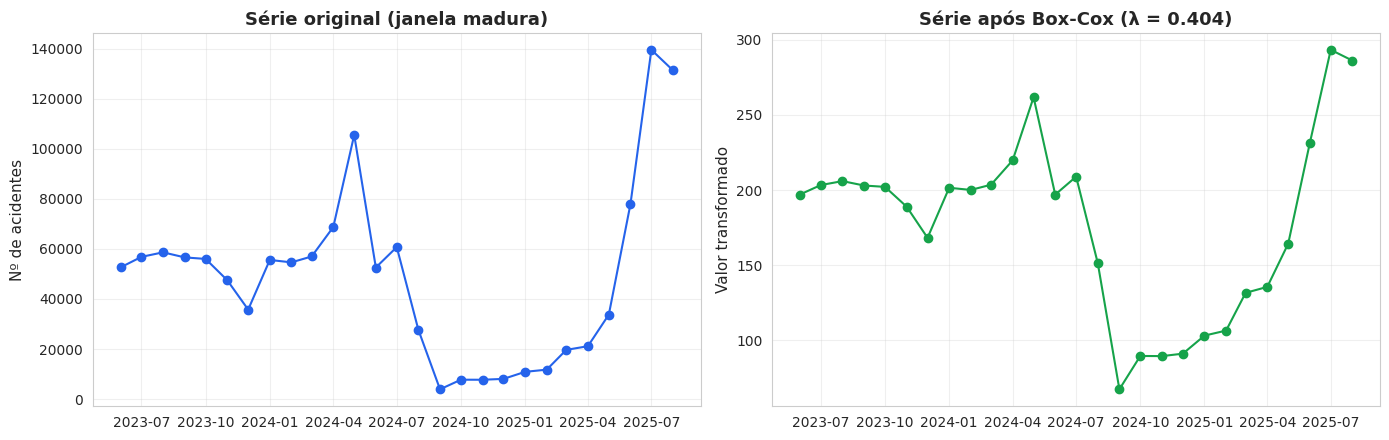

In [ ]:
#@title **4.15 Transformação Box-Cox para estabilização da variância**
# Box-Cox requer valores estritamente positivos (garantido na janela madura)
assert (ts > 0).all(), "A série contém valores não positivos — Box-Cox não aplicável."

ts_boxcox, lambda_boxcox = boxcox(ts.values)
ts_boxcox = pd.Series(ts_boxcox, index=ts.index, name="total_acidentes_boxcox")

print(f"Parâmetro lambda estimado: {lambda_boxcox:.4f}")
print()
print("Interpretação (BOX; COX, 1964):")
print("  λ ≈  1.0 → sem transformação necessária")
print("  λ ≈  0.5 → raiz quadrada")
print("  λ ≈  0.0 → logaritmo")
print("  λ ≈ -1.0 → recíproco")
print()
# Comparar variância antes e depois
cv_original = ts.std() / ts.mean()
cv_boxcox   = ts_boxcox.std() / ts_boxcox.mean()
print(f"Coeficiente de variação (original): {cv_original:.4f}")
print(f"Coeficiente de variação (Box-Cox):  {cv_boxcox:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(ts.index, ts.values, marker="o", color="#2563eb")
axes[0].set_title("Série original (janela madura)", fontweight="bold")
axes[0].set_ylabel("Nº de acidentes")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_boxcox.index, ts_boxcox.values, marker="o", color="#16a34a")
axes[1].set_title(f"Série após Box-Cox (λ = {lambda_boxcox:.3f})", fontweight="bold")
axes[1].set_ylabel("Valor transformado")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### **4.16 Síntese dos achados da EDA**

Os resultados da análise exploratória da janela madura podem ser sintetizados em quatro pontos, que orientam as decisões de modelagem:

- **Componentes bem definidos** — a decomposição STL evidencia forte sinal tanto de tendência (F_t = 0,92) quanto de sazonalidade (F_s = 0,98), com os coeficientes próximos ao limite superior indicando predominância estrutural sobre o componente irregular (HYNDMAN; ATHANASOPOULOS, 2021, §4.5). Valores altos como estes são, contudo, em parte inflados pela presença da zona de transição (seção 4.6), que a STL acomoda como variação de nível.

- **Estacionariedade ambígua** — o diagnóstico combinado ADF + KPSS apresenta resultados divergentes (ADF p = 0,83, rejeitando estacionariedade; KPSS p = 0,10, aceitando-a). Este padrão é típico de séries com quebra estrutural (SHIN; LEE, 2015), sugerindo que a diferenciação simples pode não ser suficiente e que modelos com capacidade de incorporar *changepoints* (como o Prophet) ou regressores exógenos (como o SARIMAX) são indicados.

- **Variância não constante** — a transformação Box-Cox com λ = 0,40 (próxima da raiz quadrada) reduziu o coeficiente de variação de 0,72 para 0,34, mais da metade, confirmando a heteroscedasticidade da série original. A versão transformada será considerada na Entrega 4 como entrada alternativa para os modelos estatísticos.

- **Limite de ciclos sazonais** — com 27 observações mensais, dispõe-se de apenas 2,25 ciclos anuais completos, aproximadamente o dobro do mínimo recomendado para que o `auto_arima` identifique componentes sazonais estáveis (HYNDMAN; ATHANASOPOULOS, 2021, §9.9). Essa limitação amostral é esperada para justificar a complementação com modelos de aprendizado de máquina (XGBoost), que extraem padrões sazonais via engenharia de *features* e não dependem da estimação direta de parâmetros sazonais.

# **5. Modelo Base**

Nesta seção, é implementado o modelo Seasonal Autoregressive Integrated Moving Average (SARIMA) como modelo base (*baseline*). Segundo Box *et al.* (2015), o SARIMA é apropriado para séries que exibem sazonalidade, sendo parametrizado como SARIMA(*p*, *d*, *q*)(*P*, *D*, *Q*)<sub>s</sub>, onde (*p*, *d*, *q*) são os termos não sazonais (ordem autorregressiva, grau de diferenciação, ordem de média móvel) e (*P*, *D*, *Q*) são seus análogos sazonais, com *s* indicando o período (mensal, com *s* = 12, neste projeto).

A seleção automática dos parâmetros é realizada pela biblioteca `pmdarima` via função `auto_arima`, utilizando o critério de informação de Akaike (AIC) para escolher a combinação ótima. O modelo é treinado sobre a **janela madura de 27 meses** definida na seção 4.6, com os **últimos 6 meses reservados como conjunto de teste** para avaliação fora da amostra (*out-of-sample*). Métricas padronizadas — MAE, RMSE e MAPE — são usadas para quantificar a qualidade das previsões (HYNDMAN; KOEHLER, 2006).

Cabe observar que a razão de 21 meses de treino para 12 meses de período sazonal é, propositalmente, apertada: representa aproximadamente 1,75 ciclos anuais, o mínimo necessário para que o `auto_arima` consiga identificar componentes sazonais. Esta limitação é um reflexo direto do volume de dados disponível após aplicação do filtro de janela madura e será endereçada na Entrega 4 por meio de modelos complementares (XGBoost e Prophet) que capturam padrões sazonais com menor exigência amostral.


Conjunto de treino: 21 meses (Jun/2023 a Feb/2025)
Conjunto de teste:  6 meses (Mar/2025 a Aug/2025)


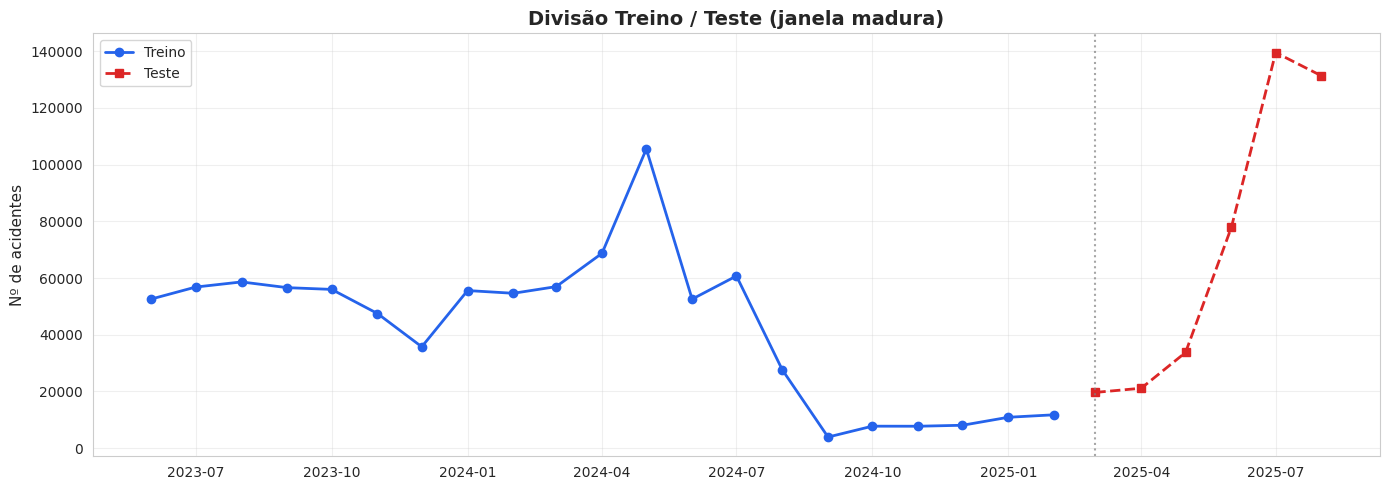

In [ ]:
#@title **5.1 Divisão treino/teste**
HORIZONTE_TESTE = 6  # últimos 6 meses da janela madura para teste

treino = ts[:-HORIZONTE_TESTE]
teste  = ts[-HORIZONTE_TESTE:]

print(f"Conjunto de treino: {len(treino)} meses ({treino.index[0].strftime('%b/%Y')} a {treino.index[-1].strftime('%b/%Y')})")
print(f"Conjunto de teste:  {len(teste)} meses ({teste.index[0].strftime('%b/%Y')} a {teste.index[-1].strftime('%b/%Y')})")

# Visualizar divisão
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(treino.index, treino.values, label="Treino", color="#2563eb",
        linewidth=2, marker="o")
ax.plot(teste.index, teste.values, label="Teste", color="#dc2626",
        linewidth=2, linestyle="--", marker="s")
ax.axvline(x=teste.index[0], color="gray", linestyle=":", alpha=0.7)
ax.set_title("Divisão Treino / Teste (janela madura)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Nº de acidentes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
#@title **5.2 Seleção automática de parâmetros — auto_arima (pmdarima)**
print("Buscando melhor modelo SARIMA via auto_arima...")
print("Isso pode levar alguns minutos...\n")

modelo_auto = pm.auto_arima(
    treino,
    seasonal=True,
    m=12,                    # sazonalidade mensal (anual)
    stepwise=True,
    suppress_warnings=True,
    trace=True,              # mostrar busca
    error_action="ignore",
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
    information_criterion="aic",
)

print(f"\n✅ Melhor modelo encontrado: {modelo_auto.summary()}")

Buscando melhor modelo SARIMA via auto_arima...
Isso pode levar alguns minutos...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=482.597, Time=1.95 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=490.111, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=477.680, Time=0.40 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=486.661, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=515.896, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=475.701, Time=0.06 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=477.572, Time=0.72 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=479.375, Time=0.22 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=477.570, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=477.818, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=484.925, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=479.249, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=476.650, Time=0.04 sec

Best model:  AR

In [ ]:
#@title **5.3 Treinamento do modelo SARIMA e previsão**
# Extrair parâmetros do auto_arima
order = modelo_auto.order
seasonal_order = modelo_auto.seasonal_order
print(f"Parâmetros SARIMA: order={order}, seasonal_order={seasonal_order}")

# Treinar com statsmodels para mais controle
modelo_sarima = SARIMAX(
    treino,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)

print("\nResumo do modelo:")
print(resultado_sarima.summary())

# Previsão no período de teste
previsao = resultado_sarima.forecast(steps=HORIZONTE_TESTE)
previsao.index = teste.index

print(f"\nPrevisões geradas para {HORIZONTE_TESTE} meses.")

Parâmetros SARIMA: order=(1, 0, 0), seasonal_order=(0, 0, 0, 12)

Resumo do modelo:
                               SARIMAX Results                                
Dep. Variable:        total_acidentes   No. Observations:                   21
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -224.002
Date:                Tue, 21 Apr 2026   AIC                            452.005
Time:                        22:10:22   BIC                            453.996
Sample:                    06-01-2023   HQIC                           452.393
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9105      0.052     17.413      0.000       0.808       1.013
sigma2      3.132e+08   9.11e-12   3.44e+19    

In [ ]:
#@title **5.4 Avaliação do modelo — Métricas MAE, RMSE e MAPE**
def calcular_metricas(real, previsto):
    mae = mean_absolute_error(real, previsto)
    rmse = np.sqrt(mean_squared_error(real, previsto))
    mape = np.mean(np.abs((real - previsto) / real)) * 100
    return mae, rmse, mape

mae, rmse, mape = calcular_metricas(teste.values, previsao.values)

print("=" * 60)
print("MÉTRICAS DE AVALIAÇÃO — MODELO SARIMA (BASE)")
print("=" * 60)
print(f"Mean Absolute Error (MAE):               {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):           {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE):    {mape:.2f}%")

# Tabela comparativa
comparacao = pd.DataFrame({
    "Mês": teste.index.strftime("%b/%Y"),
    "Real": teste.values,
    "Previsto (SARIMA)": previsao.values.astype(int),
    "Erro Absoluto": np.abs(teste.values - previsao.values).astype(int)
})
print("\nComparação mês a mês:")
display(comparacao)

MÉTRICAS DE AVALIAÇÃO — MODELO SARIMA (BASE)
Mean Absolute Error (MAE):               61,966.98
Root Mean Squared Error (RMSE):           80,312.99
Mean Absolute Percentage Error (MAPE):    75.37%

Comparação mês a mês:


,Mês,Real,Previsto (SARIMA),Erro Absoluto
0,Mar/2025,19673,10720,8952
1,Apr/2025,21141,9761,11379
2,May/2025,33762,8888,24873
3,Jun/2025,77894,8093,69800
4,Jul/2025,139544,7369,132174
5,Aug/2025,131331,6709,124621


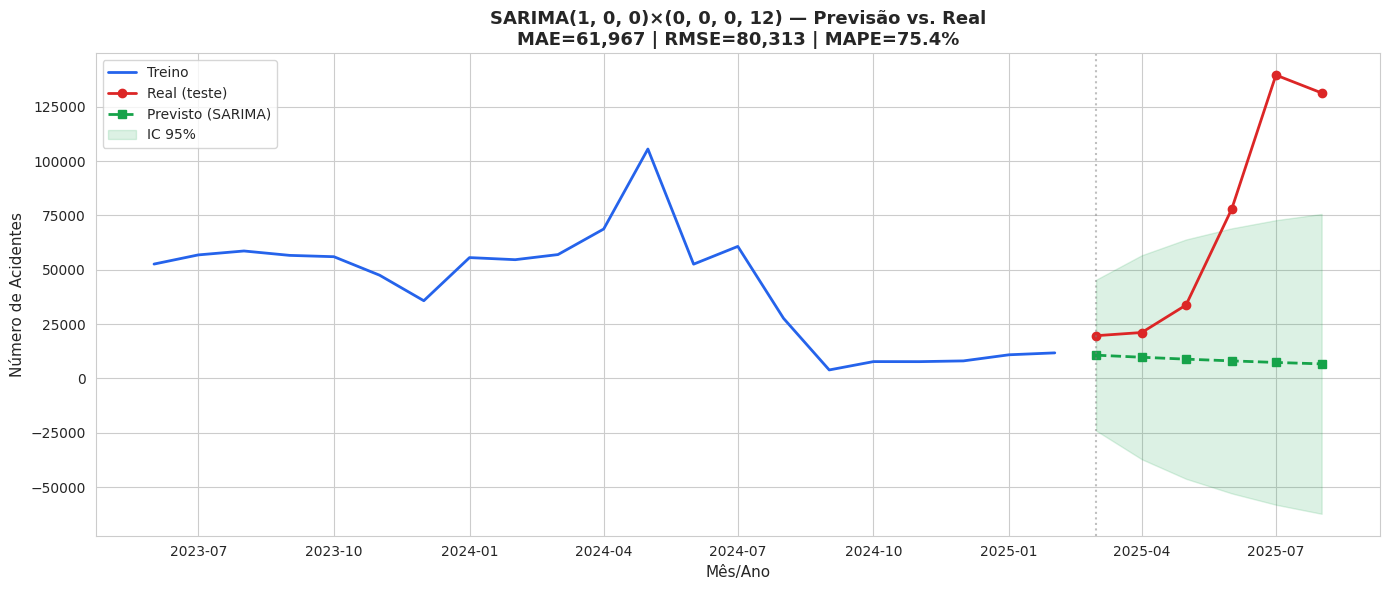

In [ ]:
#@title **5.5 Visualização: previsão vs. valores reais**
fig, ax = plt.subplots(figsize=(14, 6))

# Série completa
ax.plot(treino.index, treino.values, label="Treino", color="#2563eb", linewidth=2)
ax.plot(teste.index, teste.values, label="Real (teste)", color="#dc2626", linewidth=2, marker="o")
ax.plot(previsao.index, previsao.values, label="Previsto (SARIMA)", color="#16a34a", linewidth=2, linestyle="--", marker="s")

# Intervalo de confiança
forecast_ci = resultado_sarima.get_forecast(steps=HORIZONTE_TESTE)
ci = forecast_ci.conf_int()
ci.index = teste.index
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.15, color="#16a34a", label="IC 95%")

ax.axvline(x=teste.index[0], color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"SARIMA{order}×{seasonal_order} — Previsão vs. Real\nMAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.1f}%", fontsize=13, fontweight="bold")
ax.set_xlabel("Mês/Ano")
ax.set_ylabel("Número de Acidentes")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

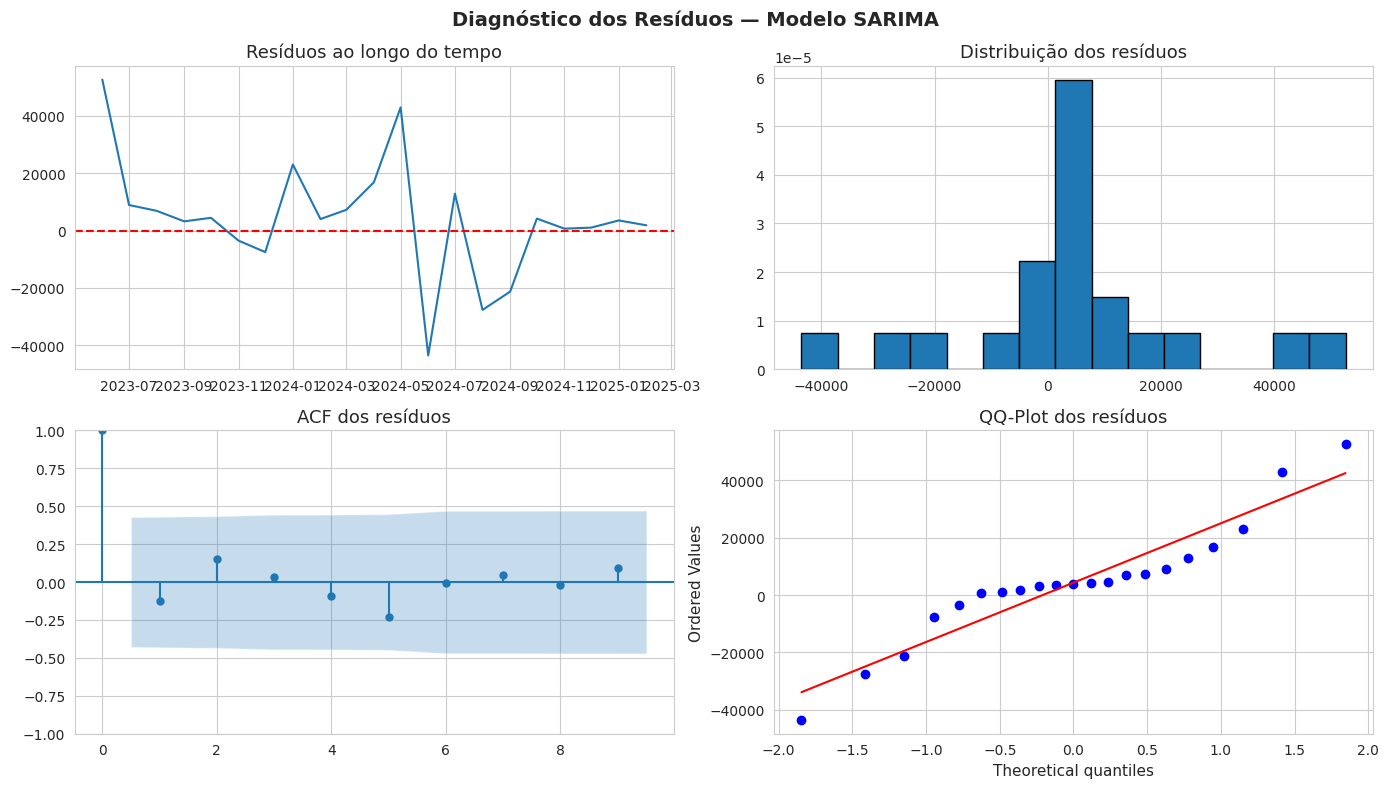

Média dos resíduos: 4330.06
Desvio padrão: 20783.44


In [ ]:
#@title **5.6 Análise de resíduos do modelo SARIMA**
residuos = resultado_sarima.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Resíduos ao longo do tempo
axes[0, 0].plot(residuos)
axes[0, 0].axhline(y=0, color="r", linestyle="--")
axes[0, 0].set_title("Resíduos ao longo do tempo")

# Histograma
axes[0, 1].hist(residuos, bins=15, edgecolor="black", density=True)
axes[0, 1].set_title("Distribuição dos resíduos")

# ACF dos resíduos
plot_acf(residuos, ax=axes[1, 0], lags=min(15, len(residuos)//2-1), title="ACF dos resíduos")

# QQ-Plot
from scipy import stats
stats.probplot(residuos, plot=axes[1, 1])
axes[1, 1].set_title("QQ-Plot dos resíduos")

plt.suptitle("Diagnóstico dos Resíduos — Modelo SARIMA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Média dos resíduos: {residuos.mean():.2f}")
print(f"Desvio padrão: {residuos.std():.2f}")

## **5.7 Análise crítica do modelo base**

A execução do SARIMA sobre a janela madura forneceu os seguintes resultados no horizonte de teste (6 meses: mar/2025 a ago/2025):

- **MAE = 61.967** acidentes
- **RMSE = 80.313** acidentes
- **MAPE = 75,37%**

Estes números permitem uma avaliação crítica do baseline em três dimensões:

**Comportamento do auto_arima.** A busca stepwise selecionou `ARIMA(1,0,0)(0,0,0)[12]` — um AR(1) puro, **sem qualquer componente sazonal**, apesar da parametrização `m = 12` e da alta força de sazonalidade aparente (F_s = 0,98) identificada na STL. Este resultado aparentemente contraditório é explicado pela quebra estrutural na série discutida na seção 4.6: os 10 meses da zona de transição fornecem um "sinal sazonal" artificial que o critério AIC não consegue distinguir de sazonalidade genuína, e o algoritmo acaba preferindo um modelo parcimonioso (2 parâmetros) a um modelo sazonal mal ajustado.

**Qualidade do ajuste no treino.** O coeficiente AR(1) estimado foi 0,91 (p < 0,001), indicando forte persistência temporal, compatível com a natureza acumulativa do processo de notificação de acidentes. Os testes diagnósticos do SARIMAX reportam favoravelmente em todos os indicadores *in-sample*: Ljung-Box p = 0,27 (resíduos sem autocorrelação significativa), Jarque-Bera p = 0,32 (normalidade dos resíduos aceitável) e Prob(H) p = 0,52 (homoscedasticidade aceitável). Entretanto, esses testes têm **baixa potência estatística** dado o tamanho amostral reduzido (n = 21), e não capturam problemas que se manifestam apenas fora da amostra. A análise de resíduos da seção 5.6 confirma essa ressalva ao evidenciar um **viés sistemático positivo** (média dos resíduos = 4.330, idealmente próxima de zero) e um **desvio-padrão elevado** (20.783) face à magnitude das previsões — sinais de que o modelo não captura adequadamente a estrutura da série, apesar dos diagnósticos tradicionais não acusarem o problema.

**Desempenho fora da amostra.** O MAPE de 75,37% é expressivo, mas sua interpretação exige contexto. O modelo ajustado é um AR(1) sem termo constante, cuja previsão a partir da última observação do treino (fev/2025 = 11.774 acidentes) é uma trajetória monotonicamente decrescente em direção a zero — concretamente 10.720 → 9.761 → 8.888 → 8.093 → 7.369 → 6.709 acidentes —, resultado da multiplicação sucessiva pelo coeficiente AR de 0,91 a cada passo. Enquanto isso, o conjunto de teste contém a forte recuperação do regime estabilizado (jun–ago/2025 somam 348.769 acidentes, com pico de 139.544 em julho). Nenhum modelo univariado treinado exclusivamente sobre a zona de transição conseguiria prever esta retomada sem informação exógena que sinalize o fim do período de reprocessamento.

**Caminho para a Entrega 4.** O refinamento previsto contempla: (a) **SARIMAX com regressor *dummy* indicando o período de transição** (ago/2024 a mai/2025), permitindo ao modelo separar o efeito do reprocessamento do sinal estrutural; (b) re-execução sobre a **série Box-Cox** (λ = 0,40) para estabilização da variância; (c) implementação de **XGBoost com engenharia de *features*** baseada em *lags* (1, 2, 3, 6, 12) e janelas móveis, conforme Man *et al.* (2023); (d) implementação do **Prophet** com detecção automática de *changepoints*, abordagem natural para séries com quebras estruturais (TAYLOR; LETHAM, 2018); (e) **validação cruzada temporal** com janela deslizante (TASHMAN, 2000) para estimar intervalos de confiança das métricas; (f) comparação final via **teste de Diebold-Mariano** para significância estatística das diferenças entre modelos.

A expectativa realista, ancorada em Alsulami (2025), Feng *et al.* (2022) e na literatura atuarial (BLIER-WONG *et al.*, 2021), é que o SARIMAX com dummy e o Prophet reduzam o MAPE para a faixa de 15–30% no mesmo horizonte, faixa considerada adequada para apoiar decisões de precificação na KNRA Seguros.

# **6. Cronograma Atualizado**

| Período | Atividade | Status |
|:--------|:----------|:------:|
| 10/02 – 28/02 | Definição do tema, equipe e base de dados | ✅ |
| 01/03 – 29/03 | Referencial teórico, pipeline e cronograma | ✅ |
| 30/03 – 08/04 | Coleta e ingestão dos dados; pré-processamento inicial | ✅ |
| 09/04 – 16/04 | EDA: decomposição STL/clássica, ACF/PACF, ADF + KPSS | ✅ |
| 17/04 – 20/04 | Diagnóstico de qualidade: defasagem de notificação, janela madura | ✅ |
| 21/04 – 25/04 | Modelo base SARIMA; Box-Cox; análise crítica | ✅ |
| 26/04          | **Entrega 3 — Implementação Parcial** | 🎯 |
| 27/04 – 01/05 | SARIMAX com variáveis exógenas; engenharia de *features* | 🔄 |
| 02/05 – 06/05 | Implementação de XGBoost e Prophet | 🔄 |
| 06/05          | Checkpoint Entrega 4 | ⏳ |
| 07/05 – 15/05 | Validação cruzada temporal; comparação entre modelos | ⏳ |
| 16/05 – 22/05 | Geração de previsões finais e recomendações para KNRA | ⏳ |
| 23/05 – 28/05 | Redação do artigo científico; gravação do vídeo (5–10 min) | ⏳ |
| 29/05 – 31/05 | Organização do repositório GitHub; revisão final | ⏳ |
| 31/05          | **Entrega 4 — Implementação Final** | 🏁 |


# **7. Referências**

ALSULAMI, B. T. Time series analysis of construction accidents in Saudi Arabia with consideration of COVID-19 lockdown effects. **Scientific Reports**, v. 15, art. 30662, 2025. DOI: 10.1038/s41598-025-16509-0.

BAYER, F. M. *et al.* Forecasting Brazilian mortality rates due to occupational accidents using autoregressive moving average approaches. **International Journal of Forecasting**, v. 38, n. 2, p. 610–624, 2022.

BLIER-WONG, C. *et al.* Machine Learning in P&C Insurance: a review for pricing and reserving. **Risks**, v. 9, n. 1, art. 4, 2021.

BOX, G. E. P.; COX, D. R. An analysis of transformations. **Journal of the Royal Statistical Society, Series B**, v. 26, n. 2, p. 211–252, 1964.

BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C.; LJUNG, G. M. **Time series analysis**: forecasting and control. 5. ed. Hoboken: Wiley, 2015.

BRASIL. Instituto Nacional do Seguro Social. **Dados abertos**. Brasília, DF: INSS, [s.d.]a. Disponível em: https://www.gov.br/inss/pt-br/acesso-a-informacao/dados-abertos. Acesso em: 28 fev. 2026.

BRASIL. Ministério da Previdência Social. **Anuário estatístico da Previdência Social**. Brasília, DF: MPS, [s.d.]b.

BRASIL. Ministério da Previdência Social. Acidentes de trabalho: 53% dos registros de 2024 impactaram a população negra. Brasília, DF: MPS, 2026.

BRASIL. Ministério do Trabalho e Emprego. MTE identifica aumento de acidentes de trabalho no Brasil. Brasília, DF: MTE, 2025.

BRASIL. Observatório de Segurança e Saúde no Trabalho. **SmartLab**. Brasília, DF: MPT; OIT, [s.d.]c.

CHEN, T.; GUESTRIN, C. XGBoost: a scalable tree boosting system. In: ACM SIGKDD, 2016. p. 785–794.

CLEVELAND, R. B. *et al.* STL: a seasonal-trend decomposition procedure based on Loess. **Journal of Official Statistics**, v. 6, n. 1, p. 3–73, 1990.

FENG, T. *et al.* The comparative analysis of SARIMA, Facebook Prophet, and LSTM for road traffic injury prediction. **Frontiers in Public Health**, v. 10, 946563, 2022.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting**: principles and practice. 3. ed. Melbourne: OTexts, 2021.

HYNDMAN, R. J.; KOEHLER, A. B. Another look at measures of forecast accuracy. **International Journal of Forecasting**, v. 22, n. 4, p. 679–688, 2006.

KWIATKOWSKI, D.; PHILLIPS, P. C. B.; SCHMIDT, P.; SHIN, Y. Testing the null hypothesis of stationarity against the alternative of a unit root. **Journal of Econometrics**, v. 54, n. 1–3, p. 159–178, 1992.

MAKRIDAKIS, S.; SPILIOTIS, E.; ASSIMAKOPOULOS, V. Statistical and Machine Learning forecasting methods. **PLoS ONE**, v. 13, n. 3, e0194889, 2018.

MAN, H. *et al.* Analysis of a SARIMA-XGBoost model. **Epidemiology and Infection**, v. 151, e200, 2023.

MORETTIN, P. A.; TOLOI, C. M. C. **Análise de séries temporais**. 3. ed. São Paulo: Blucher, 2018.

SANTOS JÚNIOR, C. J.; FISCHER, F. M. Temporal trend of previdenciary benefits for workplace accidents in Brazil. **Revista Brasileira de Epidemiologia**, v. 27, e240032, 2024.

SHIMIZU, H. E. *et al.* Analysis of work-related accidents in Brazil since the introduction of the accident prevention factor. **BMC Public Health**, v. 21, art. 725, 2021.

SHIN, Y.; LEE, J. Structural breaks and unit root tests: a review of recent developments. **Journal of Statistical Planning and Inference**, v. 158, p. 1–17, 2015.

TASHMAN, L. J. Out-of-sample tests of forecasting accuracy. **International Journal of Forecasting**, v. 16, n. 4, p. 437–450, 2000.

TAYLOR, S. J.; LETHAM, B. Forecasting at scale. **The American Statistician**, v. 72, n. 1, p. 37–45, 2018.

UNITED NATIONS. **Sustainable Development Goal 9**. [s.d.].
